In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
extent = 1
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))#(9216, 9216 + extent))#(0, extent))

In [4]:
# Rename lat/lon to j/i
emulator_patch = emulator_patch.rename({'lat': 'j', 'lon': 'i'})

# Copy over coordinates from llc_patch
emulator_patch['XC'] = llc_patch['XC']
emulator_patch['YC'] = llc_patch['YC']
emulator_patch['rA'] = llc_patch['rA']
emulator_patch['Z'] = llc_patch['Z']

In [5]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

vort_llc = ((np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2 - \
            (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2)

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
vort_llc_normalized = np.clip(vort_llc_normalized, np.nanpercentile(vort_llc_normalized, 1), np.nanpercentile(vort_llc_normalized, 99))
vort_llc_normalized = vort_llc_normalized / np.nanmax(np.abs(vort_llc_normalized))

llc_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)

In [6]:
# Emulator Patch
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

vort_emulator = ((np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2 - \
                 (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2)

vort_emulator_normalized = vort_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
vort_emulator_normalized = np.clip(vort_emulator_normalized, np.nanpercentile(vort_emulator_normalized, 1), np.nanpercentile(vort_emulator_normalized, 99))
vort_emulator_normalized = vort_emulator_normalized / np.nanmax(np.abs(vort_emulator_normalized))

emulator_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_emulator_normalized)

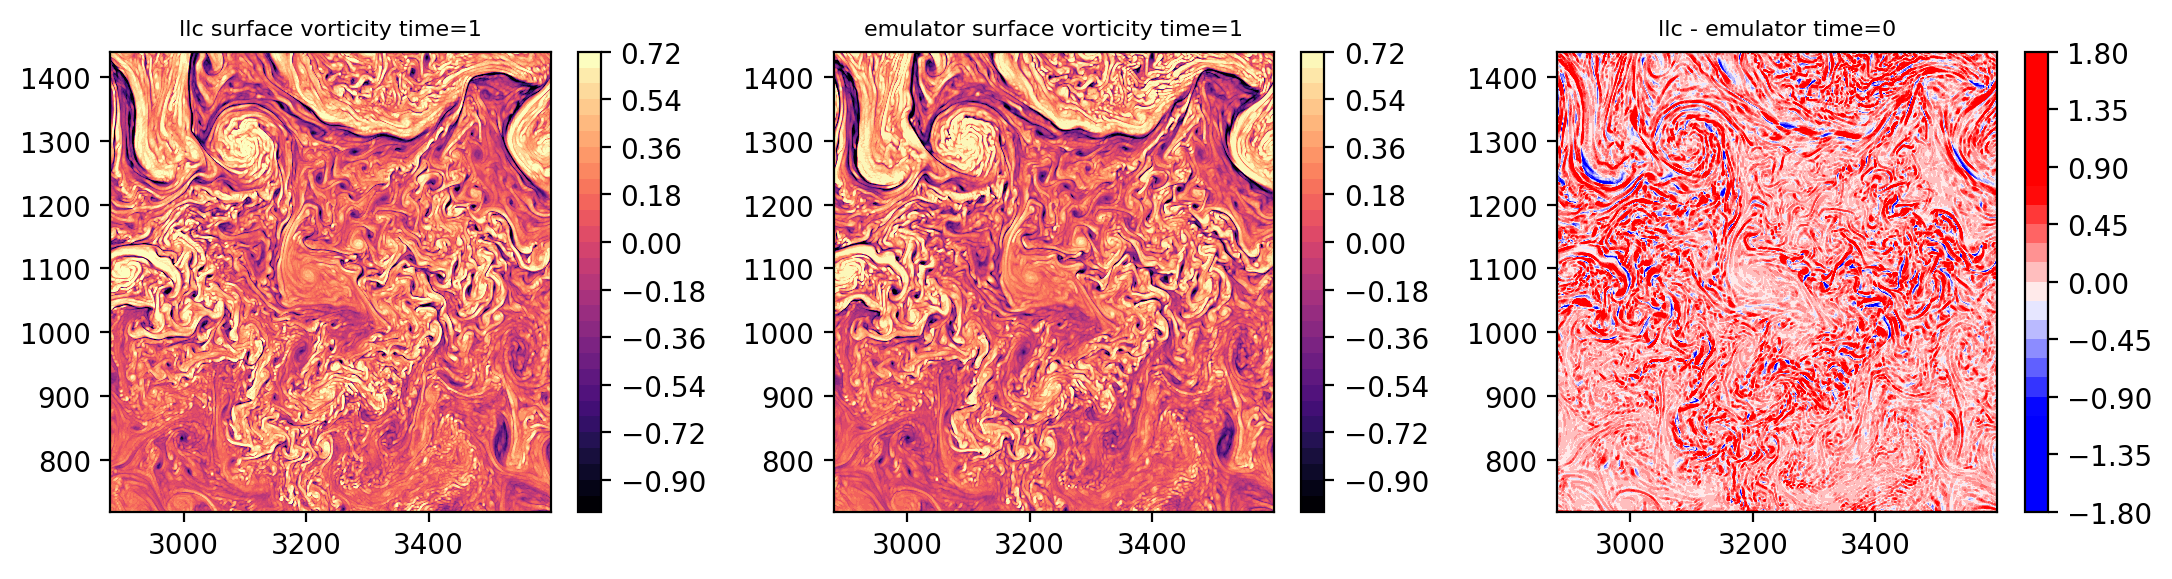

In [7]:
llc_vis = llc_patch.isel(time=0,k=0).vorticity
emulator_vis = emulator_patch.isel(time=0,k=0).vorticity

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="magma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface vorticity time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="magma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface vorticity time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="bwr",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

u_x_llc = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
u_y_llc = (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2
v_x_llc = (np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2
v_y_llc = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
sigma_llc_normalized = np.clip(sigma_llc_normalized, 0, np.nanpercentile(sigma_llc_normalized, 99))
sigma_llc_normalized = sigma_llc_normalized / np.nanmax(sigma_llc_normalized)

llc_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)

In [9]:
# Emulator Patch
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

u_x_emulator = (np.roll(emulator_patch['U'].values, -1, axis=3) - np.roll(emulator_patch['U'].values, 1, axis=3)) / 2
u_y_emulator = (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2
v_x_emulator = (np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2
v_y_emulator = (np.roll(emulator_patch['V'].values, -1, axis=2) - np.roll(emulator_patch['V'].values, 1, axis=2)) / 2

sigma_n_emulator = u_x_emulator - v_y_emulator
sigma_s_emulator = v_x_emulator + u_y_emulator
sigma_emulator = np.sqrt(sigma_n_emulator**2 + sigma_s_emulator**2)

sigma_emulator_normalized = sigma_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
sigma_emulator_normalized = np.clip(sigma_emulator_normalized, 0, np.nanpercentile(sigma_emulator_normalized, 99))
sigma_emulator_normalized = sigma_emulator_normalized / np.nanmax(sigma_emulator_normalized)

emulator_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_emulator_normalized)

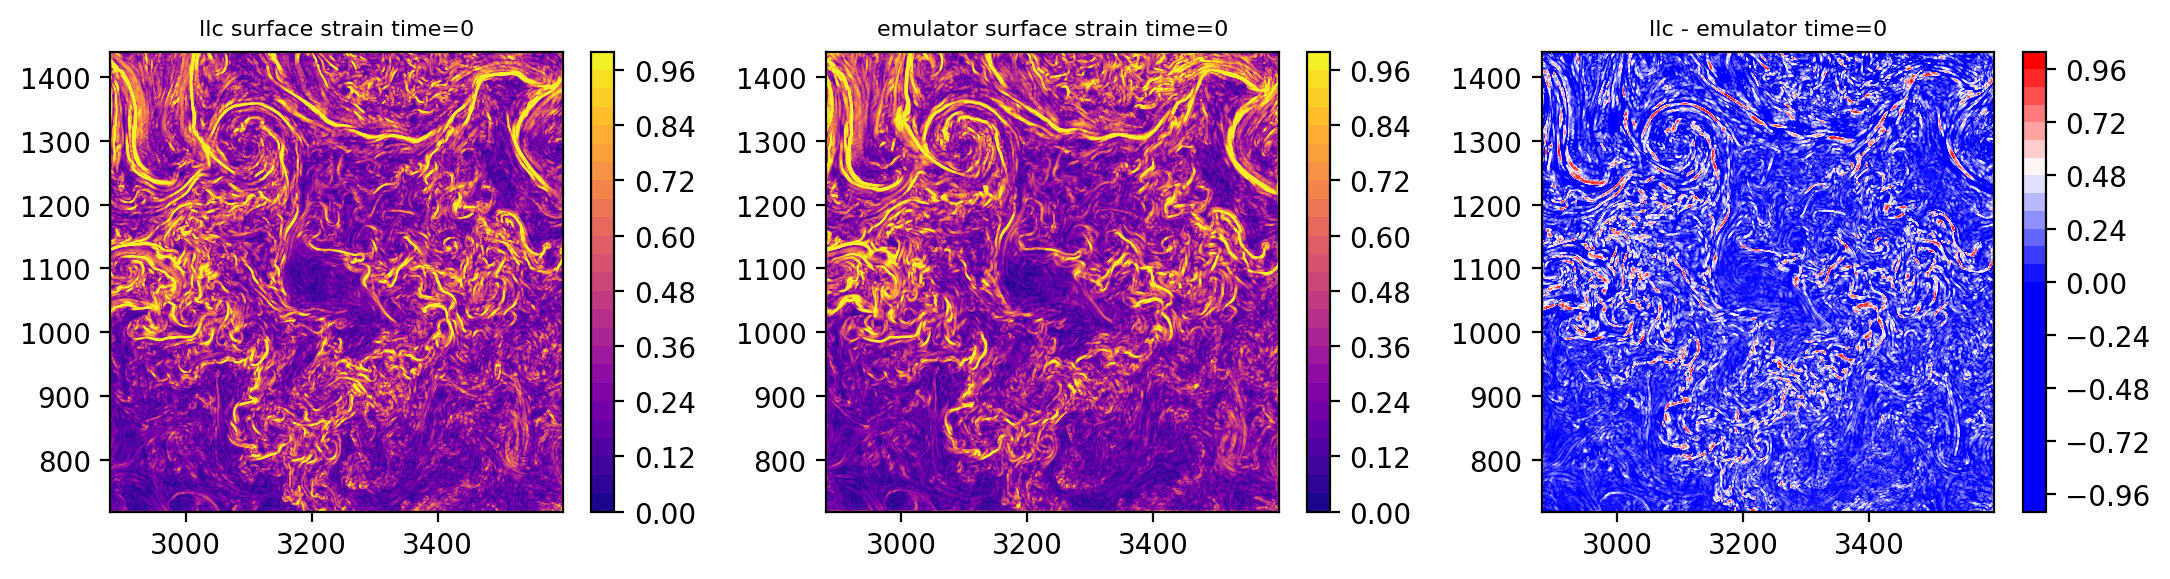

In [10]:
llc_vis = llc_patch.isel(time=0,k=0).strain
emulator_vis = emulator_patch.isel(time=0,k=0).strain

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface strain time=0', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface strain time=0', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="bwr",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
vort_hist_llc = llc_patch.vorticity.stack(vals=['time','i','j']).values
vort_hist_emulator = emulator_patch.vorticity.stack(vals=['time','i','j']).values

strain_hist_llc = llc_patch.strain.stack(vals=['time','i','j']).values
strain_hist_emulator = emulator_patch.strain.stack(vals=['time','i','j']).values

In [16]:
llc_mesh = np.meshgrid(vort_hist_llc[0][::1000], strain_hist_llc[0][::1000])
emulator_mesh = np.meshgrid(vort_hist_emulator[0][::1000], strain_hist_emulator[0][::1000])